### Look at TM scores of ESMFold synCPs to original

In [10]:
import sys
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [35]:
def tmscore(q,t, cp=True):
    ''' Run TM-align and get back TM-align score '''
    if cp:
        output = os.popen(f'/home/ubuntu/TM_tools/TMalign {q} {t} -cp')
    else:
        output = os.popen(f'/home/ubuntu/TM_tools/TMalign {q} {t}')
    tms = {"tms":[]}
    parse_float = lambda x: float(x.split("=")[1].split()[0])

    for line in output:
        line = line.rstrip()
        if line.startswith("TM-score"): 
            tms["tms"].append(parse_float(line))
    min_tms = min(tms['tms'])
    return min_tms

In [36]:
def mean_plddt(plddt_txt: str) -> float:
    """Read a per-residue pLDDT file (one float per line) and return the mean."""
    with open(plddt_txt) as fh:
        values = [float(line.strip()) for line in fh if line.strip()]
    return float(np.mean(values))
 

In [37]:
fp = '/home/ubuntu/esm/esm/1BQ7_CP/cut0188_ptm0.914_r3.plddt.txt'

In [38]:
mean_plddt(fp)

93.28914285714286

In [39]:
def collect_pdbs(data_dir: str) -> dict[str, dict[str, str]]:
    """
    Scan data_dir for files matching cutXXXX_ptm*_r*.{pdb,plddt.txt}.
    Returns {cut_id: {'pdb': path, 'plddt': path}}.
    """
    pattern = re.compile(r"^(cut\d{4})_ptm[\d.]+_r\d+\.(pdb|plddt\.txt)$")
    entries: dict[str, dict[str, str]] = {}
 
    for fname in sorted(os.listdir(data_dir)):
        m = pattern.match(fname)
        if not m:
            continue
        cut_id, ext = m.group(1), m.group(2)
        fpath = os.path.join(data_dir, fname)
        entries.setdefault(cut_id, {})
        if ext == "pdb":
            entries[cut_id]["pdb"] = fpath
        else:
            entries[cut_id]["plddt"] = fpath
 
    # keep only cuts that have both files
    complete = {k: v for k, v in entries.items() if "pdb" in v and "plddt" in v}
    return complete

In [40]:
def run(data_dir: str, out_dir: str) -> None:
    os.makedirs(out_dir, exist_ok=True)
 
    cuts = collect_pdbs(data_dir)
    if not cuts:
        sys.exit(f"No complete cut entries found in {data_dir}")
 
    if "cut0000" not in cuts:
        sys.exit("Reference cut0000 not found in directory.")
 
    ref_pdb = cuts["cut0000"]["pdb"]
    print(f"Reference: {ref_pdb}\n")
 
    records = []
    for cut_id in sorted(cuts):
        pdb_path   = cuts[cut_id]["pdb"]
        plddt_path = cuts[cut_id]["plddt"]
 
        plddt_mean = mean_plddt(plddt_path)
 
        if cut_id == "cut0000":
            tm = 1.0          # identity alignment
        else:
            tm = tmscore(ref_pdb, pdb_path)
 
        print(f"  {cut_id}  TM={tm:.4f}  pLDDT={plddt_mean:.2f}")
        records.append({"cut": cut_id, "tm_score": tm, "mean_plddt": plddt_mean})
 
    # ── save TSV ──────────────────────────────────────────────────────────────
    df = pd.DataFrame(records)
    tsv_path = os.path.join(out_dir, "tm_plddt_results.tsv")
    df.to_csv(tsv_path, sep="\t", index=False)
    print(f"\nResults saved → {tsv_path}")
 

In [57]:
df = pd.read_csv("/home/ubuntu/esm/esm/1AGY_CP/tmalign/tm_plddt_results.tsv", sep="\t")

(0.61624, 1.02)

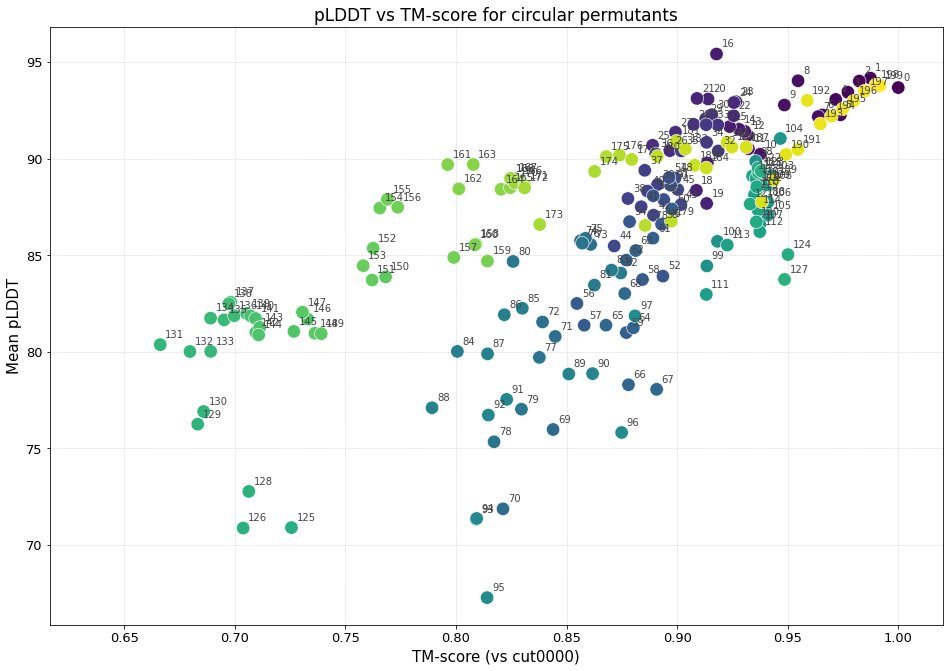

In [58]:
# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))

# colour by cut index so points are easy to distinguish
n = len(df)
cmap = mpl.colormaps["viridis"]
colours = [cmap(i / max(n - 1, 1)) for i in range(n)]

sc = ax.scatter(
    df["tm_score"], df["mean_plddt"],
    c=colours, s=180, edgecolors="white", linewidths=0.6, zorder=3
)

# label each point with just the numeric index (e.g. cut0123 → 123)
for _, row in df.iterrows():
    ax.annotate(
        row["cut"].lstrip("cut").lstrip("0") or "0",
        (row["tm_score"], row["mean_plddt"]),
        fontsize=10, ha="left", va="bottom",
        xytext=(5, 5), textcoords="offset points", color="#444"
    )

ax.set_xlabel("TM-score (vs cut0000)", fontsize=15)
ax.set_ylabel("Mean pLDDT", fontsize=15)
ax.set_title("pLDDT vs TM-score for circular permutants", fontsize=17)
ax.tick_params(axis="both", labelsize=13)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_xlim(left=max(0, df["tm_score"].min() - 0.05), right=1.02)

In [56]:
data_dir = '/home/ubuntu/esm/esm/1AGY_CP'
out_dir = '/home/ubuntu/esm/esm/1AGY_CP/tmalign'
run(data_dir,out_dir)

Reference: /home/ubuntu/esm/esm/1AGY_CP/cut0000_ptm0.933_r3.pdb

  cut0000  TM=1.0000  pLDDT=93.67
  cut0001  TM=0.9874  pLDDT=94.17
  cut0002  TM=0.9823  pLDDT=94.01
  cut0003  TM=0.9772  pLDDT=93.43
  cut0004  TM=0.9717  pLDDT=93.06
  cut0005  TM=0.9739  pLDDT=92.27
  cut0006  TM=0.9657  pLDDT=92.26
  cut0007  TM=0.9638  pLDDT=92.17
  cut0008  TM=0.9547  pLDDT=94.03
  cut0009  TM=0.9485  pLDDT=92.77
  cut0010  TM=0.9375  pLDDT=90.22
  cut0011  TM=0.9322  pLDDT=90.51
  cut0012  TM=0.9318  pLDDT=91.21
  cut0013  TM=0.9306  pLDDT=91.41
  cut0014  TM=0.9280  pLDDT=91.52
  cut0015  TM=0.9237  pLDDT=91.66
  cut0016  TM=0.9178  pLDDT=95.41
  cut0017  TM=0.9137  pLDDT=89.78
  cut0018  TM=0.9087  pLDDT=88.35
  cut0019  TM=0.9133  pLDDT=87.68
  cut0020  TM=0.9140  pLDDT=93.08
  cut0021  TM=0.9090  pLDDT=93.11
  cut0022  TM=0.9256  pLDDT=92.22
  cut0023  TM=0.9266  pLDDT=92.94
  cut0024  TM=0.9256  pLDDT=92.90
  cut0025  TM=0.8889  pLDDT=90.69
  cut0026  TM=0.8967  pLDDT=90.41
  cut0027  TM=0.8